In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving baseline_features_v2_segment_split.npz to baseline_features_v2_segment_split.npz


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 125, 7, 16)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 7, 32)      │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       444,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 447,493 (1.71 MB)

 Trainable params: 447,493 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7566 - loss: 0.7057 - val_accuracy: 0.9939 - val_loss: 0.0318
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9928 - loss: 0.0311 - val_accuracy: 0.9817 - val_loss: 0.0543
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9931 - loss: 0.0266 - val_accuracy: 0.9939 - val_loss: 0.0432
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9953 - loss: 0.0158 - val_accuracy: 0.9756 - val_loss: 0.0796
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9920 - loss: 0.0253 - val_accuracy: 0.9939 - val_loss: 0.0532
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9939 - val_loss: 0.0548
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9986 - loss: 0.0069 - val_accuracy: 0.9939 - val_loss: 0.0573
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9948 - loss: 0.0115 - val_accuracy: 0.9939 - v

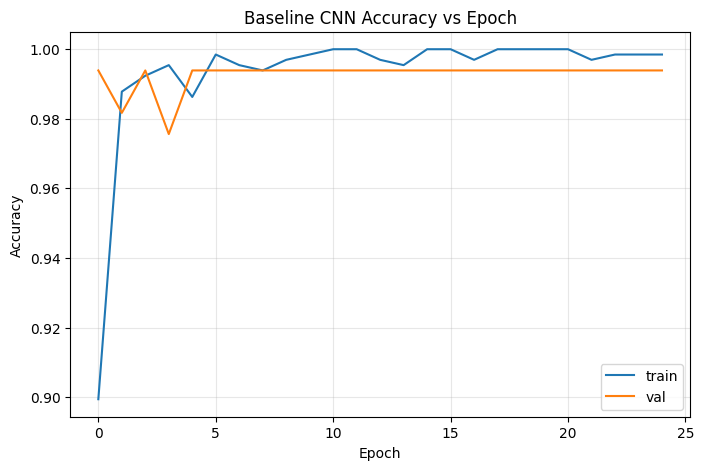

TEST accuracy: 0.8358
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


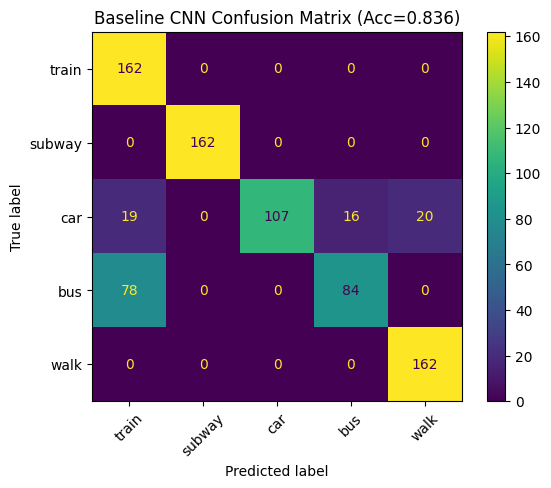

In [ ]:
# load data
data = np.load("baseline_features_v2_segment_split.npz", allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_test  = data["X_test"]
y_test  = data["y_test"]
modes   = list(data["modes"])

mode_to_idx = {m:i for i,m in enumerate(modes)}
y_train_i = np.array([mode_to_idx[y] for y in y_train], dtype=np.int64)
y_test_i  = np.array([mode_to_idx[y] for y in y_test], dtype=np.int64)

X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2], 1)),
    tf.keras.layers.Conv2D(16, (5,1), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,1)),
    tf.keras.layers.Conv2D(32, (5,1), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(modes), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# train
history = model.fit(
    X_train, y_train_i,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    verbose=1
)

# accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# test eval
test_loss, test_acc = model.evaluate(X_test, y_test_i, verbose=0)
print(f"TEST accuracy: {test_acc:.4f}")

# confusion matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test_i, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=modes)

disp.plot(cmap=None, xticks_rotation=45, values_format="d")
plt.title(f"Baseline CNN Confusion Matrix (Acc={test_acc:.3f})")
plt.show()
